# Smart Nutrition Tracker - Deep Learning Model (v2)

Notebook ini membangun sistem analisis gizi anak usia 0-6 tahun (golden age) menggunakan Deep Learning dengan TensorFlow Functional API.

## Deskripsi Proyek

Model ini dirancang untuk:
- Mengklasifikasikan status nutrisi makanan untuk anak usia dini berdasarkan skor gizi gabungan
- Memberikan rekomendasi makanan lokal berdasarkan pemenuhan AKG (Angka Kecukupan Gizi)

## Dataset

| Dataset | Sumber | Isi |
|---|---|---|
| `panganku_dataset.csv` | Web scraping panganku.org (TKPI 2017 Kemenkes RI) | 1.146 bahan makanan, 28 kolom nutrisi |
| `akg_anak.csv` | Permenkes RI No. 28 Tahun 2019 | AKG harian 4 kelompok umur anak |
| `final_dataset.csv` | Hasil data cleaning + feature engineering dari tim Data Science | Dataset siap pakai untuk modeling |

## Arsitektur Model

- **TensorFlow Functional API** untuk fleksibilitas arsitektur
- **Custom Layer**: `NutritionAttentionLayer` — belajar bobot tiap fitur nutrisi secara adaptif
- **Custom Loss Function**: `FocalLoss` — memberi penalti lebih besar pada sampel yang sulit diprediksi
- **Custom Callback**: `EarlyStoppingWithReport` — early stopping dengan laporan per-kelas setiap 10 epoch
- **Output**: Klasifikasi 4 kelas status gizi (Rendah / Cukup / Baik / Sangat Baik)

## 1. Import Library dan Konfigurasi

In [7]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

TensorFlow : 2.20.0
NumPy      : 2.2.6
Pandas     : 2.3.2


## 2. Load dan Eksplorasi Dataset

In [8]:
# Load ketiga dataset
df_panganku = pd.read_csv('panganku_dataset.csv')
df_akg      = pd.read_csv('akg_anak.csv')
df          = pd.read_csv('final_dataset.csv')

print(f"panganku_dataset : {df_panganku.shape}")
print(f"akg_anak         : {df_akg.shape}")
print(f"final_dataset    : {df.shape}")
print()
print("AKG Anak Usia 0-6 Tahun (Permenkes RI No. 28 Tahun 2019)")
print("-" * 60)
print(df_akg.to_string(index=False))

panganku_dataset : (1146, 28)
akg_anak         : (4, 18)
final_dataset    : (1146, 33)

AKG Anak Usia 0-6 Tahun (Permenkes RI No. 28 Tahun 2019)
------------------------------------------------------------
kelompok_umur  energi_kal  protein_g  lemak_g  karbohidrat_g  serat_g  air_ml  kalsium_mg  fosfor_mg  besi_mg  natrium_mg  kalium_mg  seng_mg  retinol_mcg  thiamin_mg  riboflavin_mg  niasin_mg  vit_c_mg
    0-5 bulan         550         12       34             58        0     700         200        100      0.3         120        400        2          375         0.3            0.3          3        40
   6-11 bulan         800         18       35             82       11     900         270        275     11.0         370        700        3          400         0.4            0.4          5        50
    1-3 tahun        1350         20       45            215       19    1150         650        500      7.0         800       2000        4          400         0.6            0.7    

In [9]:
# Fitur nutrisi utama (16 fitur) dari tim Data Science
FITUR_NUTRISI = [
    'energi_kal', 'protein_g', 'lemak_g', 'karbo_g',
    'serat_g',    'kalsium_mg', 'fosfor_mg', 'besi_mg',
    'natrium_mg', 'kalium_mg',  'seng_mg',  'retinol_mcg',
    'thiamin_mg', 'riboflavin_mg', 'niasin_mg', 'vit_c_mg'
]

# Fitur tambahan dari feature engineering tim DS — encode status nutrisi ke numerik
# Kurang=0, Cukup=1, Lebih=2 — memberi sinyal domain langsung ke model
STATUS_MAP = {'Kurang': 0, 'Cukup': 1, 'Lebih': 2}
for col in ['status_energi', 'status_protein', 'status_kalsium', 'status_besi']:
    df[col + '_enc'] = df[col].map(STATUS_MAP)

FITUR_STATUS = ['status_energi_enc', 'status_protein_enc', 'status_kalsium_enc', 'status_besi_enc']
FITUR_SEMUA  = FITUR_NUTRISI + FITUR_STATUS

print("Statistik Deskriptif Fitur Nutrisi")
print("-" * 40)
print(df[FITUR_NUTRISI].describe().round(2).to_string())
print()
print(f"Distribusi skor_gizi_anak:")
print(df['skor_gizi_anak'].describe().round(4))

Statistik Deskriptif Fitur Nutrisi
----------------------------------------
       energi_kal  protein_g  lemak_g  karbo_g  serat_g  kalsium_mg  fosfor_mg  besi_mg  natrium_mg  kalium_mg  seng_mg  retinol_mcg  thiamin_mg  riboflavin_mg  niasin_mg  vit_c_mg
count     1146.00    1146.00  1146.00  1146.00  1146.00     1146.00    1146.00  1146.00     1146.00    1146.00  1146.00      1146.00     1146.00        1146.00    1146.00   1146.00
mean       198.45       9.67     7.38    23.76     2.49      106.39     144.28     3.32       93.85     227.42     1.20        26.58        0.38           0.18       1.63      8.69
std        162.39      11.50    13.70    25.00     4.12      147.15     153.82     5.68      169.09     177.67     2.74       109.33        5.91           0.90       4.75     23.17
min          8.00       0.00     0.00     0.00     0.00        0.00       0.00     0.00        0.00       0.00     0.00         0.00        0.00           0.00       0.00      0.00
25%         74.00  

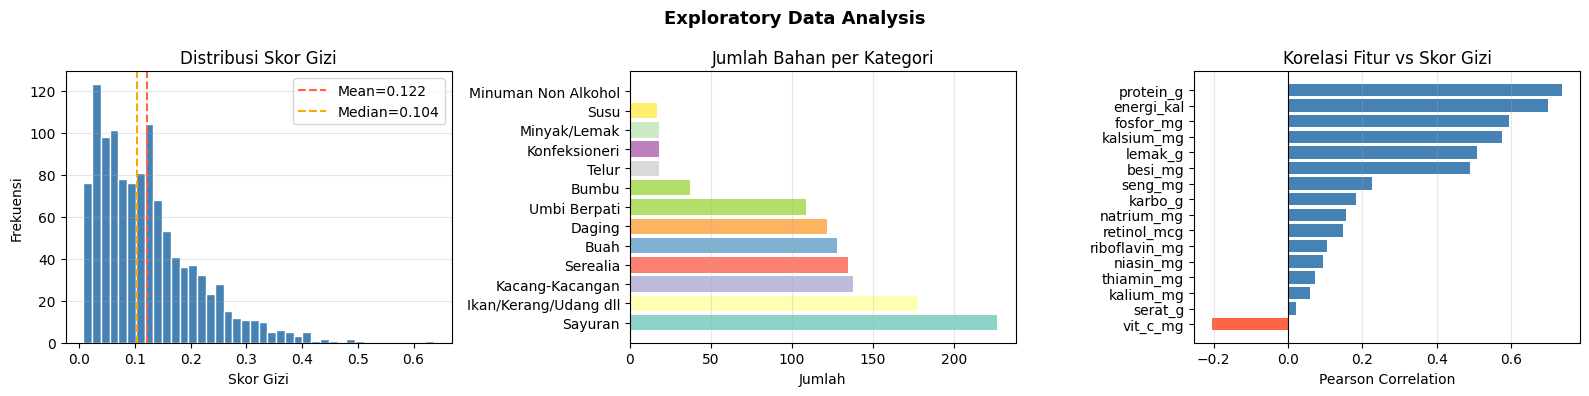

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Exploratory Data Analysis', fontsize=13, fontweight='bold')

# Distribusi skor gizi
axes[0].hist(df['skor_gizi_anak'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['skor_gizi_anak'].mean(),   color='tomato',  linestyle='--', label=f"Mean={df['skor_gizi_anak'].mean():.3f}")
axes[0].axvline(df['skor_gizi_anak'].median(), color='orange',  linestyle='--', label=f"Median={df['skor_gizi_anak'].median():.3f}")
axes[0].set_title('Distribusi Skor Gizi')
axes[0].set_xlabel('Skor Gizi')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Distribusi kategori makanan
kat_count = df['kategori'].value_counts()
axes[1].barh(kat_count.index, kat_count.values, color=plt.cm.Set3(np.linspace(0, 1, len(kat_count))))
axes[1].set_title('Jumlah Bahan per Kategori')
axes[1].set_xlabel('Jumlah')
axes[1].grid(axis='x', alpha=0.3)

# Korelasi fitur utama dengan skor gizi
corr_vals = df[FITUR_NUTRISI + ['skor_gizi_anak']].corr()['skor_gizi_anak'].drop('skor_gizi_anak').sort_values()
colors_corr = ['tomato' if v < 0 else 'steelblue' for v in corr_vals]
axes[2].barh(corr_vals.index, corr_vals.values, color=colors_corr)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Korelasi Fitur vs Skor Gizi')
axes[2].set_xlabel('Pearson Correlation')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_01_eda.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Feature Engineering: Buat Target Klasifikasi

Label kelas dibuat berdasarkan kuartil `skor_gizi_anak` agar distribusi kelas tetap seimbang.
Pendekatan ini dipilih karena:
- EDA tim DS menunjukkan 95% bahan makanan berstatus 'Kurang' secara absolut terhadap AKG
- Kuartil mempertahankan distribusi seimbang (25% per kelas) sehingga model tidak bias
- Makna kelas bersifat relatif: membedakan mana yang 'lebih baik' di antara pilihan yang ada

Fitur tambahan `status_energi_enc`, `status_protein_enc`, `status_kalsium_enc`, `status_besi_enc`
diikutsertakan sebagai sinyal domain dari tim DS untuk membantu model membedakan kelas tengah.

In [11]:
q25, q50, q75 = df['skor_gizi_anak'].quantile([0.25, 0.50, 0.75])

def buat_kelas_gizi(skor):
    if skor <= q25:
        return 0   # Rendah
    elif skor <= q50:
        return 1   # Cukup
    elif skor <= q75:
        return 2   # Baik
    else:
        return 3   # Sangat Baik

LABEL_KELAS = {0: 'Rendah', 1: 'Cukup', 2: 'Baik', 3: 'Sangat Baik'}

df['kelas_gizi'] = df['skor_gizi_anak'].apply(buat_kelas_gizi)

print("Quartile Skor Gizi:")
print(f"  Q25 = {q25:.4f}  |  Q50 = {q50:.4f}  |  Q75 = {q75:.4f}")
print()
print("Distribusi Kelas Target:")
for kls, nama in LABEL_KELAS.items():
    n = (df['kelas_gizi'] == kls).sum()
    print(f"  Kelas {kls} ({nama:<12}): {n:>4} sampel ({n/len(df)*100:.1f}%)")

Quartile Skor Gizi:
  Q25 = 0.0514  |  Q50 = 0.1044  |  Q75 = 0.1647

Distribusi Kelas Target:
  Kelas 0 (Rendah      ):  287 sampel (25.0%)
  Kelas 1 (Cukup       ):  286 sampel (25.0%)
  Kelas 2 (Baik        ):  287 sampel (25.0%)
  Kelas 3 (Sangat Baik ):  286 sampel (25.0%)


In [12]:
# Gunakan seluruh fitur: 16 nutrisi + 4 status dari tim DS
X = df[FITUR_SEMUA].values.astype(np.float32)
y = df['kelas_gizi'].values.astype(np.int32)

# Split sebelum SMOTE — SMOTE hanya boleh diterapkan pada train set
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_train_raw, y_train_raw, test_size=0.176, random_state=42, stratify=y_train_raw
)

print(f"Sebelum SMOTE:")
print(f"  Train  : {len(X_train_raw):>4} sampel")
print(f"  Val    : {len(X_val):>4} sampel")
print(f"  Test   : {len(X_test):>4} sampel")

# Standardisasi — fit hanya pada train
scaler = StandardScaler()
X_train_raw_sc = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val_sc       = scaler.transform(X_val).astype(np.float32)
X_test_sc      = scaler.transform(X_test).astype(np.float32)

# SMOTE pada train set yang sudah di-scale
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sc, y_train = smote.fit_resample(X_train_raw_sc, y_train_raw)
X_train_sc = X_train_sc.astype(np.float32)
y_train    = y_train.astype(np.int32)

print()
print(f"Setelah SMOTE:")
print(f"  Train  : {len(X_train_sc):>4} sampel")
print(f"  Distribusi kelas setelah SMOTE:")
for kls, nama in LABEL_KELAS.items():
    n = (y_train == kls).sum()
    print(f"    Kelas {kls} ({nama:<12}): {n}")

# One-hot encoding untuk categorical crossentropy
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   num_classes=4)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=4)

print()
print(f"Shape X_train_sc  : {X_train_sc.shape}")
print(f"Shape y_train_oh  : {y_train_oh.shape}")
print(f"Total fitur input : {X_train_sc.shape[1]} (16 nutrisi + 4 status)")

Sebelum SMOTE:
  Train  :  802 sampel
  Val    :  172 sampel
  Test   :  172 sampel

Setelah SMOTE:
  Train  :  804 sampel
  Distribusi kelas setelah SMOTE:
    Kelas 0 (Rendah      ): 201
    Kelas 1 (Cukup       ): 201
    Kelas 2 (Baik        ): 201
    Kelas 3 (Sangat Baik ): 201

Shape X_train_sc  : (804, 20)
Shape y_train_oh  : (804, 4)
Total fitur input : 20 (16 nutrisi + 4 status)


## 4. Komponen Kustom

Tiga komponen kustom diimplementasikan sesuai checklist Main Quest:
- **Custom Layer** — `NutritionAttentionLayer`
- **Custom Loss** — `FocalLoss`
- **Custom Callback** — `EarlyStoppingWithReport`

In [13]:
# [MAIN QUEST] Custom Layer
# NutritionAttentionLayer belajar memberi bobot berbeda tiap fitur nutrisi secara adaptif.
# Nutrisi yang lebih relevan untuk klasifikasi kelas gizi mendapat attention weight lebih tinggi.
#
# Mekanisme:
#   1. Linear projection ke ruang hidden (tanh activation)
#   2. Proyeksi kembali ke n_features (sigmoid) -> attention weights [0,1]
#   3. Hadamard product: fitur * attention_weights
#   4. Residual + LayerNorm untuk stabilitas

class NutritionAttentionLayer(layers.Layer):

    def __init__(self, hidden_units=64, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        n = input_shape[-1]
        self.W1 = self.add_weight(name='W1', shape=(n, self.hidden_units),
                                  initializer='glorot_uniform', trainable=True)
        self.b1 = self.add_weight(name='b1', shape=(self.hidden_units,),
                                  initializer='zeros', trainable=True)
        self.W2 = self.add_weight(name='W2', shape=(self.hidden_units, n),
                                  initializer='glorot_uniform', trainable=True)
        self.layer_norm = layers.LayerNormalization()
        self.dropout    = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=False):
        h       = tf.nn.tanh(tf.matmul(inputs, self.W1) + self.b1)
        weights = tf.nn.sigmoid(tf.matmul(h, self.W2))
        weights = self.dropout(weights, training=training)
        out     = self.layer_norm(inputs + inputs * weights)
        return out, weights

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'hidden_units': self.hidden_units, 'dropout_rate': self.dropout_rate})
        return cfg


# Verifikasi
_x    = tf.random.normal((4, len(FITUR_SEMUA)))
_attn = NutritionAttentionLayer(hidden_units=64, name='verify')
_out, _w = _attn(_x)
print(f"NutritionAttentionLayer OK")
print(f"  Input  : {_x.shape}")
print(f"  Output : {_out.shape}")
print(f"  Weights: {_w.shape}")

NutritionAttentionLayer OK
  Input  : (4, 20)
  Output : (4, 20)
  Weights: (4, 20)


In [14]:
# [MAIN QUEST] Custom Loss Function
# FocalLoss memberi penalti lebih besar pada sampel yang sulit diprediksi (hard examples)
# dan mengurangi kontribusi sampel mudah. Lebih efektif dari crossentropy biasa
# untuk masalah klasifikasi dengan kelas tengah yang ambiguous (kelas 'Cukup').
#
# Formula: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
# alpha diset lebih tinggi untuk kelas 1 (Cukup) karena recall-nya paling rendah di v1

class FocalLoss(keras.losses.Loss):

    def __init__(self, gamma=1.5, alpha=None, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred       = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce_loss      = -y_true * tf.math.log(y_pred)
        p_t          = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        loss         = focal_weight * ce_loss

        if self.alpha is not None:
            alpha_t = tf.constant(self.alpha, dtype=tf.float32)
            loss    = loss * alpha_t

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg


# Verifikasi
_fl = FocalLoss(gamma=1.5, alpha=[1.0, 1.8, 1.2, 1.0])
_yt = tf.constant([[1,0,0,0],[0,0,1,0]], dtype=tf.float32)
_yp = tf.constant([[0.8,0.1,0.05,0.05],[0.1,0.2,0.6,0.1]], dtype=tf.float32)
print(f"FocalLoss OK")
print(f"  Loss value: {_fl(_yt, _yp).numpy():.6f}")

FocalLoss OK
  Loss value: 0.087517


In [15]:
# [MAIN QUEST] Custom Callback
# EarlyStoppingWithReport menggabungkan early stopping standar dengan monitoring
# per-kelas setiap 10 epoch — memberikan laporan yang relevan secara domain gizi.

class EarlyStoppingWithReport(keras.callbacks.Callback):

    def __init__(self, X_val, y_val_int, patience=25, min_delta=1e-4, label_map=None):
        super().__init__()
        self.X_val        = X_val
        self.y_val_int    = y_val_int
        self.patience     = patience
        self.min_delta    = min_delta
        self.label_map    = label_map or {}
        self.best_loss    = np.inf
        self.wait         = 0
        self.best_epoch   = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss', np.inf)

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.wait         = 0
            self.best_epoch   = epoch + 1
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1

        # Laporan per-kelas setiap 10 epoch
        if (epoch + 1) % 10 == 0:
            y_pred_prob = self.model.predict(self.X_val, verbose=0)
            y_pred      = np.argmax(y_pred_prob, axis=1)
            per_kelas   = []
            for kls in sorted(self.label_map.keys()):
                mask  = self.y_val_int == kls
                if mask.sum() > 0:
                    acc_k = (y_pred[mask] == kls).mean() * 100
                    per_kelas.append(f"{self.label_map[kls]}={acc_k:.0f}%")
            info = " | ".join(per_kelas)
            print(f"  [Epoch {epoch+1:3d}] val_loss={val_loss:.5f} | {info} | wait={self.wait}/{self.patience}")

        if self.wait >= self.patience:
            self.model.set_weights(self.best_weights)
            self.model.stop_training = True
            print(f"\n  Early stopping. Best epoch: {self.best_epoch}, best val_loss: {self.best_loss:.5f}")

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
        print()
        print("=" * 50)
        print(f"Training selesai. Best epoch: {self.best_epoch}")
        print(f"Best val_loss             : {self.best_loss:.5f}")
        print("=" * 50)


print("EarlyStoppingWithReport OK")

EarlyStoppingWithReport OK


## 5. Arsitektur Model

Perubahan dari v1:
- Input bertambah dari 16 menjadi 20 fitur (tambah 4 fitur status dari tim DS)
- `hidden_units` attention layer naik dari 32 ke 64 untuk menangkap lebih banyak interaksi
- Dropout diturunkan dari 0.3 ke 0.15 — dataset kecil tidak butuh regularisasi terlalu agresif
- Ditambah block Dense(256) di awal untuk representasi yang lebih kaya sebelum attention

In [16]:
# [MAIN QUEST] TensorFlow Functional API

def build_model(n_features, n_classes=4, dropout_rate=0.15):
    """
    Model klasifikasi gizi anak dengan TensorFlow Functional API.

    Arsitektur:
        Input (20 fitur)
          -> Dense(256) + BN + Dropout         (representasi awal)
          -> NutritionAttentionLayer(64)        (custom, bobot per fitur adaptif)
          -> Dense(128) + BN + Dropout
          -> Dense(128) + BN + Residual
          -> Dense(64)  + BN + Dropout
          -> Dense(32)  + Dropout
          -> Output Dense(4, softmax)

    Parameter:
        n_features   : Jumlah fitur input
        n_classes    : Jumlah kelas output (default: 4)
        dropout_rate : Dropout rate backbone
    """
    inputs = keras.Input(shape=(n_features,), name='nutrisi_input')

    # Block awal — representasi fitur sebelum attention
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='dense_0')(inputs)
    x = layers.BatchNormalization(name='bn_0')(x)
    x = layers.Activation('relu', name='relu_0')(x)
    x = layers.Dropout(dropout_rate, name='drop_0')(x)

    # Proyeksi ke dimensi attention (n_features) untuk kompatibilitas residual
    x_proj = layers.Dense(n_features, name='proj')(x)

    # Custom attention layer
    x_att, _ = NutritionAttentionLayer(hidden_units=64, dropout_rate=0.1,
                                        name='nutrition_attention')(x_proj)

    # Block 1
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name='dense_1')(x_att)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(dropout_rate, name='drop_1')(x)

    # Block 2 + Residual
    h = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name='dense_2')(x)
    h = layers.BatchNormalization(name='bn_2')(h)
    h = layers.Activation('relu', name='relu_2')(h)
    x = layers.Add(name='residual')([x, h])
    x = layers.Dropout(dropout_rate, name='drop_2')(x)

    # Block 3
    x = layers.Dense(64, activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='drop_3')(x)

    # Block 4
    x = layers.Dense(32, activation='relu', name='dense_4')(x)
    x = layers.Dropout(0.1, name='drop_4')(x)

    # Output
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='SmartNutritionTracker_v2')
    return model


model = build_model(n_features=len(FITUR_SEMUA), n_classes=4, dropout_rate=0.15)
model.summary()

Model: "SmartNutritionTracker_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nutrisi_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_0 (Dense)     │ (None, 256)       │      5,376 │ nutrisi_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_0                │ (None, 256)       │      1,024 │ dense_0[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_0 (Activation) │ (None, 256)       │          0 │ bn_0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_0 (Dropout)    │ (None, 256)       │          0 │ relu_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj (Dense)        │ (None, 20)        │      5,140 │ drop_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nutrition_attention │ [(None, 20),      │      2,664 │ proj[0][0]        │
│ (NutritionAttentio… │ (None, 20)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,688 │ nutrition_attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 128)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 128)       │          0 │ drop_1[0][0],     │
│                     │                   │            │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 128)       │          0 │ residual[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 64)        │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ drop_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_4 (Dropout)    │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 45,152 (176.38 KB)

 Trainable params: 44,000 (171.88 KB)

 Non-trainable params: 1,152 (4.50 KB)

## 6. Training dengan Custom Training Loop (tf.GradientTape)

Training loop diimplementasikan manual menggunakan `tf.GradientTape` untuk memenuhi side quest.
TensorBoard diintegrasikan untuk monitoring metrik secara real-time.

Keuntungan custom loop dibanding `model.fit()`:
- Kontrol penuh atas setiap langkah forward pass, loss compute, dan gradient update
- Memungkinkan logika training yang lebih kompleks (misal: gradient clipping per layer)
- Lebih transparan untuk debugging

In [17]:
# [SIDE QUEST] tf.GradientTape + TensorBoard

# Konfigurasi
LOG_DIR    = 'logs/smart_nutrition_v2'
EPOCHS     = 200
BATCH_SIZE = 32
PATIENCE   = 25

# alpha: kelas 1 (Cukup) diberi bobot lebih tinggi karena recall-nya paling rendah di v1
focal_loss = FocalLoss(gamma=1.5, alpha=[1.0, 1.8, 1.2, 1.0])
optimizer  = keras.optimizers.Adam(learning_rate=5e-4)

# TensorBoard writers
train_writer = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'train'))
val_writer   = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'val'))

# Metrics
train_loss_metric = keras.metrics.Mean(name='train_loss')
train_acc_metric  = keras.metrics.CategoricalAccuracy(name='train_accuracy')
val_loss_metric   = keras.metrics.Mean(name='val_loss')
val_acc_metric    = keras.metrics.CategoricalAccuracy(name='val_accuracy')

# Dataset TF untuk batching
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_sc, y_train_oh))\
                               .shuffle(len(X_train_sc), seed=42)\
                               .batch(BATCH_SIZE)\
                               .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_sc, y_val_oh))\
                             .batch(BATCH_SIZE)\
                             .prefetch(tf.data.AUTOTUNE)

print(f"TensorBoard log dir : {LOG_DIR}")
print(f"Optimizer LR        : {optimizer.learning_rate.numpy():.0e}")
print(f"Focal Loss gamma    : {focal_loss.gamma} | alpha: {focal_loss.alpha}")

TensorBoard log dir : logs/smart_nutrition_v2
Optimizer LR        : 5e-04
Focal Loss gamma    : 1.5 | alpha: [1.0, 1.8, 1.2, 1.0]


In [18]:
@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = model(X_batch, training=True)
        loss   = focal_loss(y_batch, y_pred)
    grads = tape.gradient(loss, model.trainable_variables)
    # Gradient clipping untuk stabilitas training
    grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(y_batch, y_pred)


@tf.function
def val_step(X_batch, y_batch):
    y_pred = model(X_batch, training=False)
    loss   = focal_loss(y_batch, y_pred)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, y_pred)


# State early stopping
best_val_loss    = np.inf
best_weights     = None
wait             = 0
best_epoch       = 0
history          = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

# ReduceLROnPlateau manual
lr_wait          = 0
lr_patience      = 8
lr_factor        = 0.5
lr_min           = 1e-6

print("Memulai training dengan tf.GradientTape...")
print("=" * 60)

for epoch in range(EPOCHS):
    # Reset metrics tiap epoch
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    # Train
    for X_batch, y_batch in train_dataset:
        train_step(X_batch, y_batch)

    # Validasi
    for X_batch, y_batch in val_dataset:
        val_step(X_batch, y_batch)

    t_loss = train_loss_metric.result().numpy()
    t_acc  = train_acc_metric.result().numpy()
    v_loss = val_loss_metric.result().numpy()
    v_acc  = val_acc_metric.result().numpy()

    history['loss'].append(t_loss)
    history['accuracy'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_accuracy'].append(v_acc)

    # Log ke TensorBoard
    with train_writer.as_default():
        tf.summary.scalar('loss',     t_loss, step=epoch)
        tf.summary.scalar('accuracy', t_acc,  step=epoch)
        tf.summary.scalar('lr', optimizer.learning_rate.numpy(), step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('loss',     v_loss, step=epoch)
        tf.summary.scalar('accuracy', v_acc,  step=epoch)

    # Laporan per-kelas setiap 10 epoch (dari custom callback logic)
    if (epoch + 1) % 10 == 0:
        y_pred_prob = model.predict(X_val_sc, verbose=0)
        y_pred_cls  = np.argmax(y_pred_prob, axis=1)
        per_kelas   = []
        for kls in range(4):
            mask  = y_val == kls
            acc_k = (y_pred_cls[mask] == kls).mean() * 100 if mask.sum() > 0 else 0
            per_kelas.append(f"{LABEL_KELAS[kls]}={acc_k:.0f}%")
        info = " | ".join(per_kelas)
        print(f"  [Epoch {epoch+1:3d}] val_loss={v_loss:.5f} | val_acc={v_acc:.4f} | {info} | wait={wait}/{PATIENCE}")

    # Early stopping
    if v_loss < best_val_loss - 1e-4:
        best_val_loss = v_loss
        best_weights  = model.get_weights()
        best_epoch    = epoch + 1
        wait          = 0
        lr_wait       = 0
    else:
        wait    += 1
        lr_wait += 1

    # ReduceLROnPlateau
    if lr_wait >= lr_patience:
        current_lr = optimizer.learning_rate.numpy()
        new_lr     = max(current_lr * lr_factor, lr_min)
        optimizer.learning_rate.assign(new_lr)
        lr_wait    = 0

    if wait >= PATIENCE:
        model.set_weights(best_weights)
        print(f"\n  Early stopping. Best epoch: {best_epoch}, best val_loss: {best_val_loss:.5f}")
        break

# Restore best weights
if best_weights is not None:
    model.set_weights(best_weights)

print()
print("=" * 50)
print(f"Training selesai. Best epoch: {best_epoch}")
print(f"Best val_loss             : {best_val_loss:.5f}")
print(f"Total epoch dijalankan    : {len(history['loss'])}")
print("=" * 50)
print(f"\nTensorBoard log tersimpan di: {LOG_DIR}")
print("Jalankan: tensorboard --logdir logs/")

Memulai training dengan tf.GradientTape...
  [Epoch  10] val_loss=0.26742 | val_acc=0.8081 | Rendah=93% | Cukup=81% | Baik=58% | Sangat Baik=91% | wait=0/25
  [Epoch  20] val_loss=0.20411 | val_acc=0.8895 | Rendah=98% | Cukup=84% | Baik=84% | Sangat Baik=91% | wait=0/25
  [Epoch  30] val_loss=0.13435 | val_acc=0.9128 | Rendah=95% | Cukup=93% | Baik=81% | Sangat Baik=95% | wait=6/25
  [Epoch  40] val_loss=0.09832 | val_acc=0.9128 | Rendah=95% | Cukup=93% | Baik=79% | Sangat Baik=98% | wait=0/25
  [Epoch  50] val_loss=0.11538 | val_acc=0.9186 | Rendah=95% | Cukup=93% | Baik=81% | Sangat Baik=98% | wait=9/25
  [Epoch  60] val_loss=0.11185 | val_acc=0.9244 | Rendah=98% | Cukup=93% | Baik=84% | Sangat Baik=95% | wait=3/25
  [Epoch  70] val_loss=0.10128 | val_acc=0.9186 | Rendah=95% | Cukup=93% | Baik=84% | Sangat Baik=95% | wait=13/25
  [Epoch  80] val_loss=0.10795 | val_acc=0.9186 | Rendah=98% | Cukup=93% | Baik=81% | Sangat Baik=95% | wait=23/25

  Early stopping. Best epoch: 56, best val

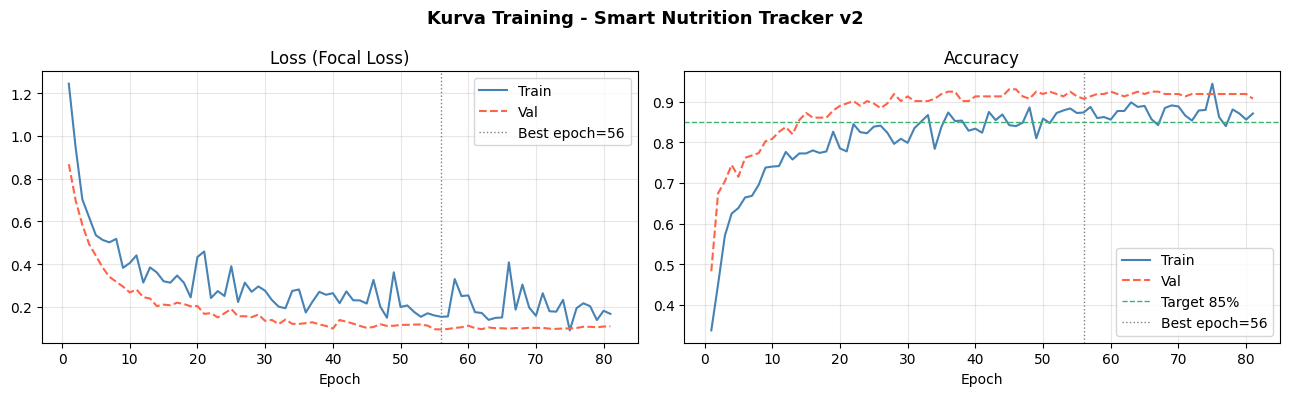

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Kurva Training - Smart Nutrition Tracker v2', fontsize=13, fontweight='bold')

ep = range(1, len(history['loss']) + 1)

axes[0].plot(ep, history['loss'],     label='Train', color='steelblue')
axes[0].plot(ep, history['val_loss'], label='Val',   color='tomato', linestyle='--')
axes[0].axvline(best_epoch, color='gray', linestyle=':', linewidth=1, label=f'Best epoch={best_epoch}')
axes[0].set_title('Loss (Focal Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['accuracy'],     label='Train', color='steelblue')
axes[1].plot(ep, history['val_accuracy'], label='Val',   color='tomato', linestyle='--')
axes[1].axhline(0.85, color='mediumseagreen', linestyle='--', linewidth=1, label='Target 85%')
axes[1].axvline(best_epoch, color='gray', linestyle=':', linewidth=1, label=f'Best epoch={best_epoch}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot_02_training.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Evaluasi Model

EVALUASI MODEL - TEST SET

              precision    recall  f1-score   support

      Rendah     0.9130    0.9767    0.9438        43
       Cukup     0.9189    0.7907    0.8500        43
        Baik     0.8723    0.9535    0.9111        43
 Sangat Baik     1.0000    0.9767    0.9882        43

    accuracy                         0.9244       172
   macro avg     0.9261    0.9244    0.9233       172
weighted avg     0.9261    0.9244    0.9233       172



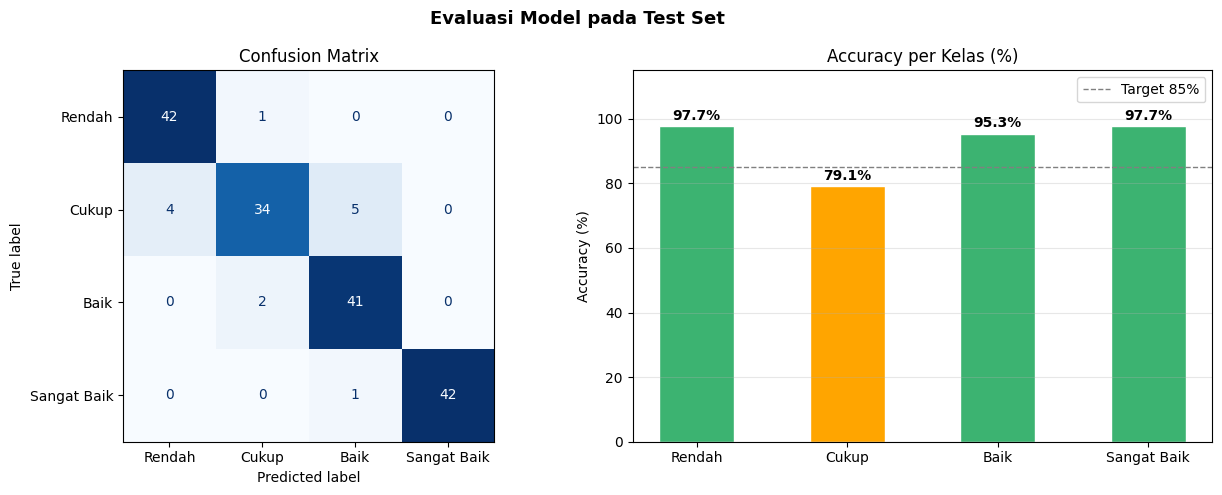

In [20]:
y_pred_prob = model.predict(X_test_sc, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
label_names = [LABEL_KELAS[i] for i in range(4)]

print("=" * 55)
print("EVALUASI MODEL - TEST SET")
print("=" * 55)
print()
print(classification_report(y_test, y_pred, target_names=label_names, digits=4))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluasi Model pada Test Set', fontsize=13, fontweight='bold')

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Per-kelas accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
bar_colors    = ['tomato' if v < 60 else 'orange' if v < 80 else 'mediumseagreen' for v in per_class_acc]
axes[1].bar(label_names, per_class_acc, color=bar_colors, edgecolor='white', width=0.5)
axes[1].axhline(85, color='gray', linestyle='--', linewidth=1, label='Target 85%')
axes[1].set_title('Accuracy per Kelas (%)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 115)
axes[1].legend()
for i, v in enumerate(per_class_acc):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_03_evaluasi.png', dpi=120, bbox_inches='tight')
plt.show()

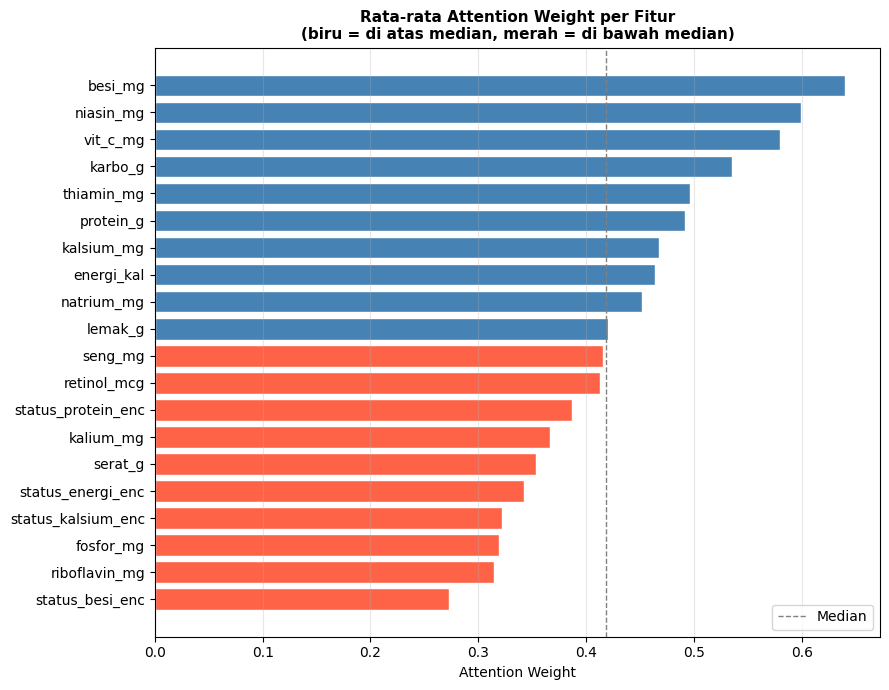

Top 5 fitur paling diperhatikan model:
     fitur  attention
thiamin_mg   0.496208
   karbo_g   0.535583
  vit_c_mg   0.580261
 niasin_mg   0.599368
   besi_mg   0.640603


In [21]:
# Visualisasi attention weight — nutrisi mana yang paling diperhatikan model
attention_extractor = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer('nutrition_attention').output,
    name    = 'attention_extractor'
)

_, attn_weights = attention_extractor.predict(X_test_sc, verbose=0)
mean_attn = attn_weights.mean(axis=0)

# Ambil hanya 16 fitur nutrisi (bukan status_enc) untuk visualisasi yang lebih bersih
# karena attention layer menerima n_features fitur setelah proyeksi
attn_df = pd.DataFrame({'fitur': FITUR_SEMUA[:len(mean_attn)], 'attention': mean_attn})
attn_df = attn_df.sort_values('attention', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_a = ['tomato' if v < attn_df['attention'].median() else 'steelblue' for v in attn_df['attention']]
ax.barh(attn_df['fitur'], attn_df['attention'], color=colors_a, edgecolor='white')
ax.axvline(attn_df['attention'].median(), color='gray', linestyle='--', linewidth=1, label='Median')
ax.set_title('Rata-rata Attention Weight per Fitur\n(biru = di atas median, merah = di bawah median)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Attention Weight')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_04_attention.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 fitur paling diperhatikan model:")
print(attn_df.tail(5)[['fitur', 'attention']].to_string(index=False))

## 8. Simpan Model dan Inference Engine

Model disimpan dalam format `.keras` (format TensorFlow siap produksi).
Parameter scaler dan metadata disimpan terpisah dalam JSON untuk keperluan deployment.

In [22]:
# [MAIN QUEST] Simpan model format .keras

MODEL_PATH  = 'smart_nutrition_tracker.keras'
SCALER_PATH = 'scaler_params.json'

model.save(MODEL_PATH)
print(f"Model disimpan: {MODEL_PATH}")

# Simpan parameter scaler dan metadata
scaler_meta = {
    'mean'         : scaler.mean_.tolist(),
    'std'          : scaler.scale_.tolist(),
    'features'     : FITUR_SEMUA,
    'features_nutrisi': FITUR_NUTRISI,
    'label_map'    : {str(k): v for k, v in LABEL_KELAS.items()},
    'quartiles'    : {'q25': float(q25), 'q50': float(q50), 'q75': float(q75)},
    'status_map'   : STATUS_MAP
}
with open(SCALER_PATH, 'w') as f:
    json.dump(scaler_meta, f, indent=2)
print(f"Scaler params disimpan: {SCALER_PATH}")

# Verifikasi load
model_verify = keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'NutritionAttentionLayer': NutritionAttentionLayer,
        'FocalLoss': FocalLoss
    }
)
diff = np.max(np.abs(
    model.predict(X_test_sc[:5], verbose=0) -
    model_verify.predict(X_test_sc[:5], verbose=0)
))
print(f"Verifikasi load model: max diff = {diff:.2e} ({'LULUS' if diff < 1e-5 else 'GAGAL'})")

Model disimpan: smart_nutrition_tracker.keras
Scaler params disimpan: scaler_params.json
Verifikasi load model: max diff = 0.00e+00 (LULUS)


In [23]:
# [SIDE QUEST] Kode inference model
# NutritionInferenceEngine menyediakan antarmuka bersih untuk prediksi
# tanpa perlu mengurus preprocessing secara manual.

class NutritionInferenceEngine:
    """
    Engine inference untuk Smart Nutrition Tracker.

    Contoh penggunaan:
        engine = NutritionInferenceEngine('smart_nutrition_tracker.keras',
                                          'scaler_params.json')
        result = engine.predict({'energi_kal': 154, 'protein_g': 12.4, ...})
    """

    def __init__(self, model_path: str, scaler_path: str):
        with open(scaler_path) as f:
            meta = json.load(f)

        self.model = keras.models.load_model(
            model_path,
            custom_objects={
                'NutritionAttentionLayer': NutritionAttentionLayer,
                'FocalLoss': FocalLoss
            }
        )
        self.mean       = np.array(meta['mean'],  dtype=np.float32)
        self.std        = np.array(meta['std'],   dtype=np.float32)
        self.features   = meta['features']
        self.feat_nutr  = meta['features_nutrisi']
        self.label_map  = {int(k): v for k, v in meta['label_map'].items()}
        self.status_map = meta['status_map']
        self.quartiles  = meta['quartiles']
        print(f"Model loaded: {model_path}")

    def _compute_status(self, data: dict, akg_ref: dict) -> dict:
        """
        Hitung status nutrisi (Kurang/Cukup/Lebih) secara otomatis
        berdasarkan nilai nutrisi dan AKG referensi.
        """
        status = {}
        for key, akg_val in akg_ref.items():
            nilai = data.get(key, 0.0)
            if nilai < akg_val * 0.5:
                status[key] = 'Kurang'
            elif nilai <= akg_val:
                status[key] = 'Cukup'
            else:
                status[key] = 'Lebih'
        return status

    def _preprocess(self, data: dict, akg_ref: dict = None) -> np.ndarray:
        # Hitung status jika akg_ref diberikan, atau default ke Kurang
        if akg_ref:
            status = self._compute_status(data, akg_ref)
        else:
            status = {'energi_kal': 'Kurang', 'protein_g': 'Kurang',
                      'kalsium_mg': 'Kurang', 'besi_mg': 'Kurang'}

        feat_vals = [data.get(f, 0.0) for f in self.feat_nutr]
        feat_vals += [
            self.status_map.get(status.get('energi_kal', 'Kurang'), 0),
            self.status_map.get(status.get('protein_g',  'Kurang'), 0),
            self.status_map.get(status.get('kalsium_mg', 'Kurang'), 0),
            self.status_map.get(status.get('besi_mg',    'Kurang'), 0),
        ]
        x = np.array(feat_vals, dtype=np.float32)
        return ((x - self.mean) / (self.std + 1e-8)).reshape(1, -1)

    def predict(self, data: dict, akg_ref: dict = None) -> dict:
        """
        Prediksi kelas gizi untuk satu bahan makanan (per 100g).

        Parameter:
            data    : dict {nama_fitur: nilai_nutrisi}
            akg_ref : dict AKG referensi untuk hitung status (opsional)

        Return:
            dict berisi kelas, label, probabilitas per kelas, dan rekomendasi
        """
        x_sc  = self._preprocess(data, akg_ref)
        probs = self.model.predict(x_sc, verbose=0)[0]
        kelas = int(np.argmax(probs))
        label = self.label_map[kelas]

        rekomendasi_map = {
            0: 'Tidak dianjurkan sebagai makanan utama anak usia dini.',
            1: 'Dapat digunakan, kombinasikan dengan sumber nutrisi lebih kaya.',
            2: 'Baik untuk menu harian anak. Variasikan dengan sumber nutrisi lain.',
            3: 'Sangat direkomendasikan untuk menu anak usia 0-6 tahun.'
        }

        return {
            'kelas'        : kelas,
            'label'        : label,
            'probabilitas' : {self.label_map[i]: round(float(p), 4) for i, p in enumerate(probs)},
            'confidence'   : round(float(probs[kelas]), 4),
            'rekomendasi'  : rekomendasi_map[kelas]
        }

    def predict_batch(self, df_input: pd.DataFrame, akg_ref: dict = None) -> pd.DataFrame:
        """
        Prediksi batch untuk DataFrame berisi banyak bahan makanan.
        """
        rows = []
        for _, row in df_input.iterrows():
            rows.append(self._preprocess(row.to_dict(), akg_ref)[0])
        X_sc  = np.array(rows, dtype=np.float32)
        probs = self.model.predict(X_sc, verbose=0)
        kelas = np.argmax(probs, axis=1)

        result = df_input.copy()
        result['pred_kelas']      = kelas
        result['pred_label']      = [self.label_map[k] for k in kelas]
        result['pred_confidence'] = probs.max(axis=1).round(4)
        return result


# Demo single prediction
engine = NutritionInferenceEngine('smart_nutrition_tracker.keras', 'scaler_params.json')
print()

telur_ayam = {
    'energi_kal': 154, 'protein_g': 12.4, 'lemak_g': 10.8,
    'karbo_g': 0.7,    'serat_g': 0.0,    'kalsium_mg': 54,
    'fosfor_mg': 180,  'besi_mg': 2.7,    'natrium_mg': 122,
    'kalium_mg': 134,  'seng_mg': 1.1,    'retinol_mcg': 140,
    'thiamin_mg': 0.12,'riboflavin_mg': 0.35, 'niasin_mg': 0.1,
    'vit_c_mg': 0.0
}

hasil = engine.predict(telur_ayam)
print("Prediksi - Telur Ayam (per 100g)")
print("-" * 40)
for k, v in hasil.items():
    print(f"  {k:<15}: {v}")

Model loaded: smart_nutrition_tracker.keras

Prediksi - Telur Ayam (per 100g)
----------------------------------------
  kelas          : 1
  label          : Cukup
  probabilitas   : {'Rendah': 0.0049, 'Cukup': 0.8778, 'Baik': 0.1167, 'Sangat Baik': 0.0006}
  confidence     : 0.8778
  rekomendasi    : Dapat digunakan, kombinasikan dengan sumber nutrisi lebih kaya.


In [24]:
# [SIDE QUEST] Generative AI — Rekomendasi Menu via LLM API
# Fitur tambahan: berdasarkan kelas gizi bahan makanan, minta rekomendasi
# menu lengkap yang sesuai untuk anak usia 0-6 tahun dari Generative AI.
#
# Ganti ANTHROPIC_API_KEY dengan API key yang valid sebelum dijalankan.

import urllib.request

ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY', 'your-api-key-here')


def rekomendasikan_menu_llm(nama_makanan: str, hasil_prediksi: dict,
                             usia_bulan: int = 12) -> str:
    """
    Minta rekomendasi menu dari LLM berdasarkan hasil klasifikasi model.

    Parameter:
        nama_makanan    : Nama bahan makanan
        hasil_prediksi  : Output dari engine.predict()
        usia_bulan      : Usia anak dalam bulan (default 12 = 1 tahun)

    Return:
        str rekomendasi menu dari LLM
    """
    label      = hasil_prediksi['label']
    confidence = hasil_prediksi['confidence']
    prob_str   = ', '.join([f"{k}: {v}" for k, v in hasil_prediksi['probabilitas'].items()])

    prompt = f"""Kamu adalah ahli gizi anak Indonesia.

Bahan makanan '{nama_makanan}' telah diklasifikasikan oleh model machine learning dengan hasil:
- Kelas gizi: {label} (confidence: {confidence:.2%})
- Distribusi probabilitas: {prob_str}

Berikan rekomendasi menu praktis untuk anak usia {usia_bulan} bulan menggunakan bahan ini.
Sertakan:
1. Satu contoh menu lengkap (sarapan/makan siang/makan malam)
2. Bahan pendamping yang direkomendasikan untuk melengkapi nutrisi
3. Cara penyajian yang sesuai usia
4. Catatan khusus jika kelas gizi 'Rendah' atau 'Cukup'

Jawab dalam Bahasa Indonesia, singkat dan praktis."""

    payload = json.dumps({
        'model'     : 'claude-sonnet-4-20250514',
        'max_tokens': 1000,
        'messages'  : [{'role': 'user', 'content': prompt}]
    }).encode('utf-8')

    req = urllib.request.Request(
        'https://api.anthropic.com/v1/messages',
        data    = payload,
        headers = {
            'Content-Type'      : 'application/json',
            'x-api-key'         : ANTHROPIC_API_KEY,
            'anthropic-version' : '2023-06-01'
        }
    )

    try:
        with urllib.request.urlopen(req) as resp:
            data = json.loads(resp.read().decode('utf-8'))
            return data['content'][0]['text']
    except Exception as e:
        return f"LLM API error: {e}"


# Demo — hanya dijalankan jika API key sudah diset
if ANTHROPIC_API_KEY != 'your-api-key-here':
    rekomendasi = rekomendasikan_menu_llm('Telur Ayam', hasil, usia_bulan=12)
    print("Rekomendasi Menu dari LLM:")
    print("-" * 50)
    print(rekomendasi)
else:
    print("Set ANTHROPIC_API_KEY di environment variable untuk mengaktifkan fitur rekomendasi LLM.")
    print()
    print("Contoh output yang diharapkan:")
    print("-" * 50)
    print("Menu Sarapan: Bubur ayam telur dengan sayuran")
    print("Bahan pendamping: Bayam (kalsium), Wortel (Vitamin A), Tahu (protein)")
    print("Cara penyajian: Haluskan untuk bayi < 12 bulan, cincang untuk 1-2 tahun")

Set ANTHROPIC_API_KEY di environment variable untuk mengaktifkan fitur rekomendasi LLM.

Contoh output yang diharapkan:
--------------------------------------------------
Menu Sarapan: Bubur ayam telur dengan sayuran
Bahan pendamping: Bayam (kalsium), Wortel (Vitamin A), Tahu (protein)
Cara penyajian: Haluskan untuk bayi < 12 bulan, cincang untuk 1-2 tahun


In [25]:
# Batch prediction + top rekomendasi per kelas
df_pred = engine.predict_batch(df)

print("Rekomendasi Top 5 Makanan per Kelas Gizi")
print("=" * 60)

for kls in range(3, -1, -1):
    subset = df_pred[df_pred['pred_kelas'] == kls].nlargest(5, 'pred_confidence')
    print(f"\nKelas {kls} - {LABEL_KELAS[kls]} (top 5 confidence tertinggi):")
    print("-" * 55)
    tampil = subset[['nama', 'kategori', 'energi_kal', 'protein_g',
                      'pred_label', 'pred_confidence']].reset_index(drop=True)
    tampil.index += 1
    print(tampil.to_string())

print()
print("Distribusi prediksi seluruh dataset:")
for kls, nama in LABEL_KELAS.items():
    n = (df_pred['pred_kelas'] == kls).sum()
    print(f"  Kelas {kls} ({nama:<12}): {n:>4} ({n/len(df)*100:.1f}%)")

Rekomendasi Top 5 Makanan per Kelas Gizi

Kelas 3 - Sangat Baik (top 5 confidence tertinggi):
-------------------------------------------------------
                                                  nama               kategori  energi_kal  protein_g   pred_label  pred_confidence
1       Lamtoro var. gung tanpa kulit (White leadtree)        Kacang-Kacangan       367.0       46.4  Sangat Baik           0.9563
2                          Sapi, paru, dendeng, mentah                 Daging       360.0       57.3  Sangat Baik           0.9474
3                   Ikan sale lais, mentah (Sheatfish)  Ikan/Kerang/Udang dll       415.0       61.3  Sangat Baik           0.9428
4  Teh melati daun kering (Tea, jasmine, black, dried)          Konfeksioneri       299.0       24.1  Sangat Baik           0.9422
5                     Ikan Teri, kering, tawar, mentah  Ikan/Kerang/Udang dll       331.0       68.7  Sangat Baik           0.9403

Kelas 2 - Baik (top 5 confidence tertinggi):
------------------